# Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import FactorAnalysis
import pingouin as pg
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import math

# Load Data (Internet Required)

In [4]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1Dmy11XxB85wDM37S5MTCdGrlQ4zmzmTHGIcwUIj0eyU/export?format=csv")
print(f"Jumlah Responden: {df.shape[0]}")
# df = df.iloc[:68]
# df.to_csv("DataBefore_7.csv")

Jumlah Responden: 69


# Handle Invalid Respondent Input

# Rename Columns

In [5]:
df = df.rename(columns={'Kelas \n(Kelas LAB / Survey Sampling and Methodology)' : 'Kelas'})

In [6]:
new_columns_var_y = {
    old: f"Y{i+1}"
    for i, old in enumerate(df.columns[3:23])
}

In [7]:
df = df.rename(columns=new_columns_var_y)

In [8]:
df.iloc[:, 0:5].head()

,Timestamp,Kelas,Gender,Y1,Y2
0,5/13/2026 17:29:21,LC09,Pria,2,5
1,5/13/2026 18:16:32,LA09,Wanita,2,2
2,5/13/2026 19:23:32,LB09,Pria,3,2
3,5/13/2026 19:31:11,LB09,Pria,2,3
4,5/13/2026 21:07:03,LB09,Wanita,1,1


In [9]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,"Selama periode Mid Exam (Semester 4), saya yakin mampu menyelesaikan tugas atau soal yang sulit jika saya berusaha dengan sungguh-sungguh.","Selama periode Mid Exam (Semester 4), ketika menghadapi hambatan dari orang lain, saya mampu menemukan jalan tengah dan cara untuk mencapai tujuan akademik saya\n(misal: keluarga, teman, atau orang lainnya)"
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [10]:
new_columns_var_x = {
    old: f"X{i+1}"
    for i, old in enumerate(df.columns[23:33])
}

In [11]:
df = df.rename(columns=new_columns_var_x)

In [12]:
df.iloc[:, 20:25].head()

,Y18,Y19,Y20,X1,X2
0,4,3,5,3,3
1,4,5,5,3,2
2,3,3,2,4,3
3,3,4,3,3,3
4,4,4,1,3,3


In [13]:
df.iloc[:, 28:33].head()

,X6,X7,X8,X9,X10
0,3,2,3,2,2
1,3,2,2,2,2
2,4,3,3,3,2
3,4,3,4,3,4
4,3,3,3,3,3


# Split DataFrame
Variable Y for Clustering = Target<br>
VAriable X + 'Gender' + 'Kelas' + 'label' for Classification

In [14]:
timestamps = [
    '5/23/2026 12:30:10',
    '5/23/2026 12:31:58'
]

df.loc[
    df['Timestamp'].isin(timestamps),
    'Kelas'
] = 'LD09'

df[df['Timestamp'].isin(timestamps)] 

,Timestamp,Kelas,Gender,Y1,Y2,Y3,Y4,Y5,Y6,Y7,...,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
55,5/23/2026 12:30:10,LD09,Pria,2,2,5,5,4,2,5,...,3,3,3,3,3,3,3,3,3,3
56,5/23/2026 12:31:58,LD09,Pria,2,4,2,2,2,2,4,...,4,4,3,4,4,4,3,4,4,4


In [15]:
var_y = df.iloc[:, 3:23]

In [16]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [17]:
var_x = df.iloc[:, 23:33]

In [18]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


# Variable Setup

## Variable Y

In [19]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


Sub Skala Dari Indikator Variabel Y (ASI | Academic Stress Inventory)
- Faktor 2 (Result Stress) : 1 - 5
- Faktor 3 (Tests Stress) : 6 - 9
- Faktor 5 (Peer Stress) : 10 - 13
- Faktor 6 (Time Management Stress) : 14 - 16
- Faktor 7 (Self-Inflicted Stress) : 17 - 20

In [20]:
subscale_items_y = {
    "Y - Faktor 2": [i for i in var_y.columns[:5]],
    "Y - Faktor 3": [i for i in var_y.columns[5:9]],
    "Y - Faktor 5": [i for i in var_y.columns[9:13]],
    "Y - Faktor 6": [i for i in var_y.columns[13:16]],
    "Y - Faktor 7": [i for i in var_y.columns[16:]]
}

In [21]:
subscale_items_y

{'Y - Faktor 2': ['Y1', 'Y2', 'Y3', 'Y4', 'Y5'],
 'Y - Faktor 3': ['Y6', 'Y7', 'Y8', 'Y9'],
 'Y - Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'],
 'Y - Faktor 6': ['Y14', 'Y15', 'Y16'],
 'Y - Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20']}

## Variable X

In [22]:
var_x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3,3,2,2,3,3,2,3,2,2
1,3,2,2,2,2,3,2,2,2,2
2,4,3,3,2,2,4,3,3,3,2
3,3,3,3,2,3,4,3,4,3,4
4,3,3,2,2,3,3,3,3,3,3


In [23]:
items_x = [i for i in var_x.columns]

# Measurement Quality
- Validity
- Reliability
- Response Bias

## Validity

### a. Corrected Item-Total Correlation

In [24]:
def get_r_table(n, alpha = 0.05): # alpha sesuai perhitungan awal 0.05
    t_dis = stats.t.ppf(1 - alpha/2, df = n - 2)
    return t_dis / np.sqrt(t_dis**2 + (n - 2))

def item_total_check(df, items, label):
    print('='*50)
    print(f" {label}")
    print('='*50)
    print(f"{'item':<12} {'r':>6} {'p':>6} {'status'}")
    
    n = len(df)
    r_tabel = get_r_table(n)
    
    total = df[items].sum(axis = 1)
    valid_count = 0
    
    for item in items:
        corrected_total = total - df[item] # corrected -> dikurangi nilai nya sendiri
        r, p = stats.pearsonr(df[item], corrected_total)
        status = "Valid" if r >= r_tabel and p < 0.05 else "Not Valid"
        
        if status == "Valid":
            valid_count += 1
        
        p_str = f"{p:.3f}" if p >= 0.001 else "<0.001"
        print(f"{item:<12} {r:>6.3f} {p_str:>7} {status}")
    
    print("\nValid:", valid_count, "/", len(items), "items")

In [25]:
for name, items in subscale_items_y.items():
    item_total_check(var_y, items, f"{name}")

 Y - Faktor 2
item              r      p status
Y1            0.605  <0.001 Valid
Y2            0.454  <0.001 Valid
Y3            0.495  <0.001 Valid
Y4            0.647  <0.001 Valid
Y5            0.551  <0.001 Valid

Valid: 5 / 5 items
 Y - Faktor 3
item              r      p status
Y6            0.549  <0.001 Valid
Y7            0.288   0.016 Valid
Y8            0.495  <0.001 Valid
Y9            0.272   0.024 Valid

Valid: 4 / 4 items
 Y - Faktor 5
item              r      p status
Y10           0.467  <0.001 Valid
Y11           0.501  <0.001 Valid
Y12           0.327   0.006 Valid
Y13           0.459  <0.001 Valid

Valid: 4 / 4 items
 Y - Faktor 6
item              r      p status
Y14           0.733  <0.001 Valid
Y15           0.750  <0.001 Valid
Y16           0.327   0.006 Valid

Valid: 3 / 3 items
 Y - Faktor 7
item              r      p status
Y17           0.761  <0.001 Valid
Y18           0.501  <0.001 Valid
Y19           0.367   0.002 Valid
Y20           0.564  <0.001 Valid


In [26]:
item_total_check(var_x, items_x, "X")

 X
item              r      p status
X1            0.541  <0.001 Valid
X2            0.466  <0.001 Valid
X3            0.707  <0.001 Valid
X4            0.588  <0.001 Valid
X5            0.550  <0.001 Valid
X6            0.496  <0.001 Valid
X7            0.619  <0.001 Valid
X8            0.757  <0.001 Valid
X9            0.738  <0.001 Valid
X10           0.718  <0.001 Valid

Valid: 10 / 10 items


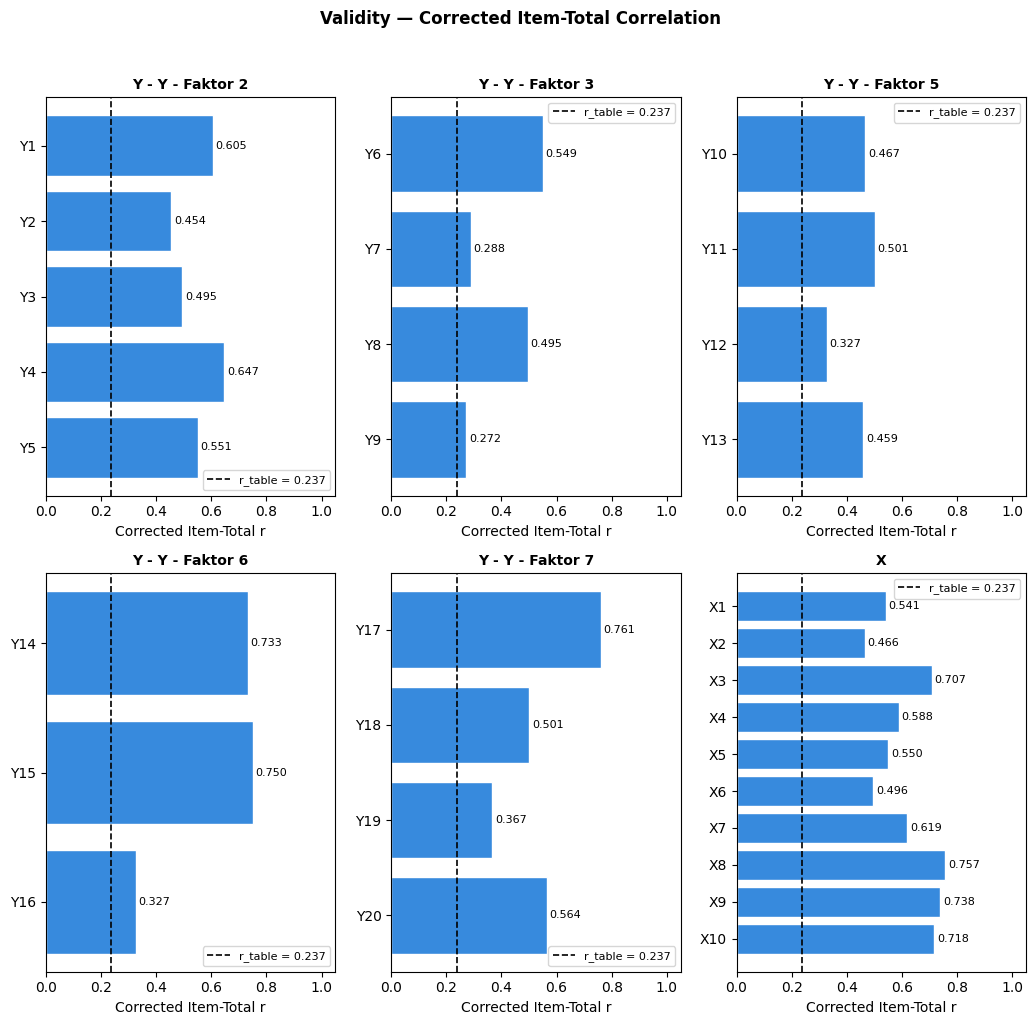

In [27]:
def get_validity_results(df, items):
    n = len(df)
    r_tabel = get_r_table(n)
    total = df[items].sum(axis=1)
    results = []
    for item in items:
        corrected_total = total - df[item]
        r, p = stats.pearsonr(df[item], corrected_total)
        status = "Valid" if r >= r_tabel and p < 0.05 else "Not Valid"
        results.append({"item": item, "r": r, "p": p, "status": status})
    return results, r_tabel

# Kumpulkan semua hasil
all_results = []
for name, items in subscale_items_y.items():
    res, r_tabel = get_validity_results(var_y, items)
    for r in res:
        r["group"] = f"Y - {name}"
    all_results.extend(res)

res_x, r_tabel = get_validity_results(var_x, items_x)
for r in res_x:
    r["group"] = "X"
all_results.extend(res_x)

validity_df = pd.DataFrame(all_results)

groups = validity_df["group"].unique()
n_groups = len(groups)
n_cols = math.ceil(n_groups / 2)
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 5 * n_rows), sharey=False)
axes = axes.flatten()  # supaya bisa di-loop linear

for ax, group in zip(axes, groups):
    sub = validity_df[validity_df["group"] == group].reset_index(drop=True)
    colors = ["#378ADD" if s == "Valid" else "#E24B4A" for s in sub["status"]]
    
    bars = ax.barh(sub["item"], sub["r"], color=colors, edgecolor="white")
    ax.axvline(r_tabel, color="black", linestyle="--", linewidth=1.2, label=f"r_table = {r_tabel:.3f}")
    
    for bar, r_val in zip(bars, sub["r"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{r_val:.3f}", va="center", fontsize=8)
    
    ax.set_title(group, fontsize=10, fontweight="bold")
    ax.set_xlabel("Corrected Item-Total r")
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

# Sembunyikan axes kosong kalau n_groups ganjil (tidak pas mengisi grid)
for ax in axes[n_groups:]:
    ax.axis("off")

fig.suptitle("Validity — Corrected Item-Total Correlation", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Reliability

Kriteria Alpha per sub-skala:

| Alpha | Interpretasi |
|---|---|
| ≥ 0.90 | Excellent |
| 0.80 – 0.89 | Good |
| 0.70 – 0.79 | Acceptable |
| 0.60 – 0.69 | Questionable |
| < 0.60 | Poor |

In [28]:
def cronbach_alpha(df, items):
    subset = df[items]
    k = len(items)
    var_items = subset.var(axis=0, ddof=1).sum() # total dari variance item indikator / soal indikator
    var_res = subset.sum(axis=1).var(ddof=1) # variance dari total jawaban responden 1 dengan responden lainnya
    return (k / (k - 1)) * (1 - var_items / var_res)

def interpret_alpha(a):
    if a >= 0.8 and a <= 1.0: return "Very High Reliability"
    if a >= 0.6 and a < 0.8: return "High Reliability"
    if a >= 0.4 and a < 0.6: return "Medium Reliability"
    if a >= 0.2 and a < 0.4: return "Low Reliability"
    if a >= -1.0 and a < 0.2: return "Very Low Reliability"

In [29]:
print("=== Cronbach's Alpha per Sub-Skala Y ===\n")
print(f"{'Sub-Skala':<35} {'Alpha':>6}  {'Interpretasi'}")
print("-" * 60)

# Faktor-Faktor Y
for nama, items in subscale_items_y.items():
    a = cronbach_alpha(var_y, items)
    print(f"{nama:<35} {a:>6.3f}  {interpret_alpha(a)}")

# Alpha total Y
print("\n=== Cronbach's Alpha Total Y ===\n")
a_y = cronbach_alpha(var_y, var_y.columns)
print("-" * 60)
print(f"{'Y (Total)':<35} {a_y:>6.3f}  {interpret_alpha(a_y)}")
print("-" * 60)

# Alpha X
print("\n=== Cronbach's Alpha X ===\n")
a_x = cronbach_alpha(var_x, items_x)
print("-" * 60)
print(f"{'X':<35} {a_x:>6.3f}  {interpret_alpha(a_x)}")
print("-" * 60)

=== Cronbach's Alpha per Sub-Skala Y ===

Sub-Skala                            Alpha  Interpretasi
------------------------------------------------------------
Y - Faktor 2                         0.774  High Reliability
Y - Faktor 3                         0.618  High Reliability
Y - Faktor 5                         0.657  High Reliability
Y - Faktor 6                         0.755  High Reliability
Y - Faktor 7                         0.747  High Reliability

=== Cronbach's Alpha Total Y ===

------------------------------------------------------------
Y (Total)                            0.845  Very High Reliability
------------------------------------------------------------

=== Cronbach's Alpha X ===

------------------------------------------------------------
X                                    0.884  Very High Reliability
------------------------------------------------------------


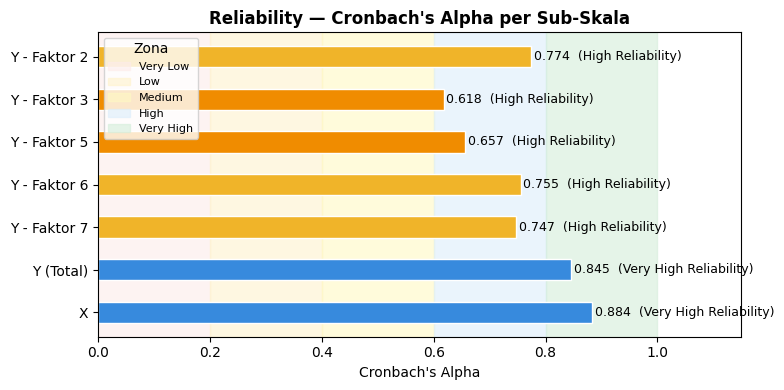

In [30]:
alpha_data = []
for name, items in subscale_items_y.items():
    a = cronbach_alpha(var_y, items)
    alpha_data.append({"label": f"{name}", "alpha": a})

alpha_data.append({"label": "Y (Total)", "alpha": cronbach_alpha(var_y, var_y.columns.tolist())})
alpha_data.append({"label": "X", "alpha": cronbach_alpha(var_x, items_x)})

alpha_df = pd.DataFrame(alpha_data)

fig, ax = plt.subplots(figsize=(8, 4))

# Zona warna background
zones = [
    (0.0, 0.20, "#FDECEA", "Very Low"),
    (0.20, 0.40, "#FEF3CD", "Low"),
    (0.40, 0.60, "#FFF9C4", "Medium"),
    (0.60, 0.80, "#DCEEFB", "High"),
    (0.80, 1.00, "#D4EDDA", "Very High"),
]
for x0, x1, color, label in zones:
    ax.axvspan(x0, x1, color=color, alpha=0.6, label=label)

colors = []
for a in alpha_df["alpha"]:
    if a >= 0.90:   colors.append("#1D9E75")
    elif a >= 0.80: colors.append("#378ADD")
    elif a >= 0.70: colors.append("#F0B429")
    elif a >= 0.60: colors.append("#F08C00")
    else:           colors.append("#E24B4A")

bars = ax.barh(alpha_df["label"], alpha_df["alpha"], color=colors, edgecolor="white", height=0.5)

for bar, a_val in zip(bars, alpha_df["alpha"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{a_val:.3f}  ({interpret_alpha(a_val)})", va="center", fontsize=9)

ax.set_xlim(0, 1.15)
ax.set_xlabel("Cronbach's Alpha")
ax.set_title("Reliability — Cronbach's Alpha per Sub-Skala", fontweight="bold")
ax.invert_yaxis()
ax.legend(loc="upper left", fontsize=8, title="Zona")
plt.tight_layout()
plt.show()

## Response Bias

**1. Acquiescence Bias**
- Hitung rata-rata jawaban per responden
- Flagging kalau mean ≥ 4 secara konsisten
- Plot: histogram distribusi mean per responden

**2. Extreme Response Bias**
- Hitung proporsi jawaban 1 atau 5 per responden
- Flagging kalau > 40% jawabannya ekstrem
- Plot: histogram proporsi ekstrem per responden

**3. Straight-lining**
- Hitung variance jawaban per responden
- Flagging kalau variance = 0 (semua jawaban sama persis)
- Plot: tidak perlu, cukup list siapa saja yang straight-liner

---

Laporannya biasanya berbentuk:

> *"Dari 100 responden, ditemukan 3 straight-liner dan 8 responden dengan extreme response rate > 40%, sehingga dieksklusi dari analisis."*

Responden yang ter-flag **bisa dieksklusi** sebelum lanjut ke analisis utama, tapi keputusan eksklusi harus dicatat dan dijelaskan.

---


### a. Acquiescence Bias

In [31]:
y_mean = var_y.mean(axis = 1) / 5
y_high_acq = y_mean >= 0.8
y_low_acq = y_mean <= 0.2
y_acq_flag = y_high_acq | y_low_acq
y_acq_flag.value_counts()

False    64
True      5
Name: count, dtype: int64

In [32]:
x_mean = var_x.mean(axis = 1) / 4
x_high_acq = x_mean >= 0.8
x_low_acq = x_mean <= 0.2
x_acq_flag = x_high_acq | x_low_acq
x_acq_flag.value_counts()

False    47
True     22
Name: count, dtype: int64

### b. Extreme Response Bias

In [33]:
extreme_y = var_y.apply(lambda r: ((r == 1) | (r == 5)).mean(), axis = 1)
extreme_y_flag = extreme_y > 0.4
extreme_y_flag.value_counts()

False    53
True     16
Name: count, dtype: int64

In [34]:
extreme_y_mid = var_y.apply(lambda r: ((r == 3)).mean(), axis = 1)
extreme_y_mid_flag = extreme_y_mid > 0.4
extreme_y_mid_flag.value_counts()

False    55
True     14
Name: count, dtype: int64

In [35]:
extreme_x = var_x.apply(lambda r: ((r == 1) | (r == 4)).mean(), axis = 1)
extreme_x_flag = extreme_x > 0.4
extreme_x_flag.value_counts()

False    59
True     10
Name: count, dtype: int64

### c. Straight Lining

In [36]:
straight_y = var_y.var(axis = 1) == 0
straight_x = var_x.var(axis = 1) == 0
straight_flag = straight_y | straight_x
straight_flag.value_counts()

False    63
True      6
Name: count, dtype: int64

### Summary

In [37]:
# ── Summary ──────────────────────────────────────────────────
print("=== Response Bias Summary ===\n")
print(f"Total responden              : {len(df)}")
print(f"\n--- Variabel Y (skala 1-5) ---")
print(f"Acquiescence (≥80% max)      : {y_acq_flag.sum()} ({y_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_y_flag.sum()} ({extreme_y_flag.mean()*100:.1f}%)")
print(f"Extreme response mid (>40%)  : {extreme_y_mid_flag.sum()} ({extreme_y_mid_flag.mean()*100:.1f}%)")

print(f"\n--- Variabel X (skala 1-4) ---")
print(f"Acquiescence (≥80% max)      : {x_acq_flag.sum()} ({x_acq_flag.mean()*100:.1f}%)")
print(f"Extreme response (>40%)      : {extreme_x_flag.sum()} ({extreme_x_flag.mean()*100:.1f}%)")

print(f"\n--- Straight-lining ---")
print(f"Y straight-liners            : {straight_y.sum()}")
print(f"X straight-liners            : {straight_x.sum()}")

=== Response Bias Summary ===

Total responden              : 69

--- Variabel Y (skala 1-5) ---
Acquiescence (≥80% max)      : 5 (7.2%)
Extreme response (>40%)      : 16 (23.2%)
Extreme response mid (>40%)  : 14 (20.3%)

--- Variabel X (skala 1-4) ---
Acquiescence (≥80% max)      : 22 (31.9%)
Extreme response (>40%)      : 10 (14.5%)

--- Straight-lining ---
Y straight-liners            : 1
X straight-liners            : 6


- Straight-lining → Perlu drop kaena tidak representatif jawaban responden
- Extreme response → Drop jika dicurigai hanya menjawab nilai extreme saja
- Acquiescence → dipertimbangkan karena bisa saja pola umum responden
- Midpoint → catat sebagai catatan, drop opsional

In [38]:
flagged_y = y_acq_flag | extreme_y_flag | straight_y
print(f"\nTotal ter-flag y             : {flagged_y.sum()} responden")
if flagged_y.sum() > 0:
    print(f"Index responden              : {list(df[flagged_y].index)}")

flagged_x = x_acq_flag | extreme_x_flag | straight_x
print(f"\nTotal ter-flag x             : {flagged_x.sum()} responden")
if flagged_x.sum() > 0:
    print(f"Index responden              : {list(df[flagged_x].index)}")

flagged = flagged_x | flagged_y
print(f"\nTotal ter-flag               : {flagged.sum()} responden")
if flagged.sum() > 0:
    print(f"Index responden              : {list(df[flagged].index)}")


Total ter-flag y             : 17 responden
Index responden              : [0, 5, 6, 20, 21, 26, 27, 32, 34, 39, 41, 43, 50, 59, 61, 63, 66]

Total ter-flag x             : 26 responden
Index responden              : [3, 5, 23, 25, 26, 32, 34, 36, 37, 39, 42, 43, 45, 46, 51, 52, 54, 55, 56, 58, 59, 60, 61, 65, 67, 68]

Total ter-flag               : 35 responden
Index responden              : [0, 3, 5, 6, 20, 21, 23, 25, 26, 27, 32, 34, 36, 37, 39, 41, 42, 43, 45, 46, 50, 51, 52, 54, 55, 56, 58, 59, 60, 61, 63, 65, 66, 67, 68]


In [39]:
bias_summary = pd.DataFrame({
    'acq_y':     y_acq_flag,
    'acq_x':     x_acq_flag,
    'extreme_y': extreme_y_flag,
    'extreme_x': extreme_x_flag,
    'straight_x_or_y': straight_flag,
})

bias_summary['total_bias'] = bias_summary.sum(axis=1)
print(bias_summary[bias_summary['total_bias'] > 0])

    acq_y  acq_x  extreme_y  extreme_x  straight_x_or_y  total_bias
0    True  False       True      False            False           2
3   False   True      False      False            False           1
5   False   True       True       True             True           4
6   False  False       True      False            False           1
20   True  False       True      False            False           2
21   True  False       True      False            False           2
23  False   True      False      False            False           1
25  False   True      False       True            False           2
26   True   True       True      False            False           3
27  False  False       True      False            False           1
32  False  False      False      False             True           1
34  False   True       True       True            False           3
36  False   True      False      False            False           1
37  False  False      False      False          

### Plot Response Bias

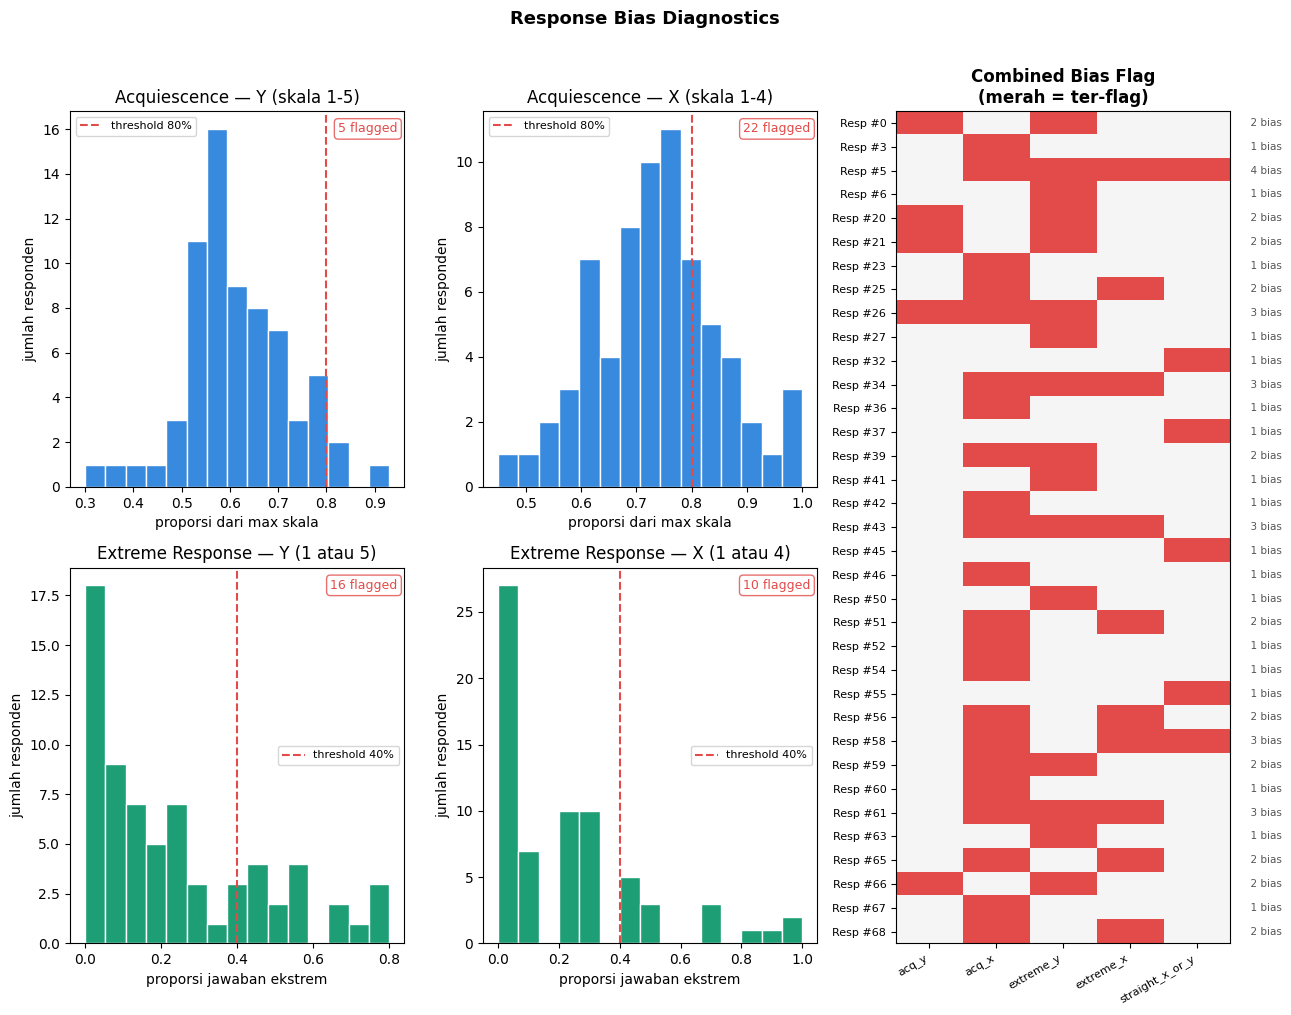

In [40]:
fig = plt.figure(figsize=(13, 10))

# Helper: hitung flagged count dan tambahkan anotasi ke plot
def annotate_flagged(ax, flag_series, threshold, orientation="vertical"):
    n_flagged = flag_series.sum()
    ax.text(0.98, 0.97, f"{n_flagged} flagged",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#E24B4A",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#E24B4A", alpha=0.8))

# ── Baris 1: Acquiescence ─────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(y_mean, bins=15, color="#378ADD", edgecolor="white")
ax1.axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
ax1.set_title("Acquiescence — Y (skala 1-5)")
ax1.set_xlabel("proporsi dari max skala")
ax1.set_ylabel("jumlah responden")
ax1.legend(fontsize=8)
annotate_flagged(ax1, y_acq_flag, 0.8)

ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(x_mean, bins=15, color="#378ADD", edgecolor="white")
ax2.axvline(0.8, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 80%")
ax2.set_title("Acquiescence — X (skala 1-4)")
ax2.set_xlabel("proporsi dari max skala")
ax2.set_ylabel("jumlah responden")
ax2.legend(fontsize=8)
annotate_flagged(ax2, x_acq_flag, 0.8)

# ── Baris 1: Extreme Response ─────────────────────────────────
ax3 = fig.add_subplot(2, 3, 4)
ax3.hist(extreme_y, bins=15, color="#1D9E75", edgecolor="white")
ax3.axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
ax3.set_title("Extreme Response — Y (1 atau 5)")
ax3.set_xlabel("proporsi jawaban ekstrem")
ax3.set_ylabel("jumlah responden")
ax3.legend(fontsize=8)
annotate_flagged(ax3, extreme_y_flag, 0.4)

ax4 = fig.add_subplot(2, 3, 5)
ax4.hist(extreme_x, bins=15, color="#1D9E75", edgecolor="white")
ax4.axvline(0.4, color="#E24B4A", linestyle="--", linewidth=1.5, label="threshold 40%")
ax4.set_title("Extreme Response — X (1 atau 4)")
ax4.set_xlabel("proporsi jawaban ekstrem")
ax4.set_ylabel("jumlah responden")
ax4.legend(fontsize=8)
annotate_flagged(ax4, extreme_x_flag, 0.4)

# ── Combined Bias Heatmap ─────────────────────────────────────
ax5 = fig.add_subplot(1, 3, 3)

heatmap_data = bias_summary[bias_summary["total_bias"] > 0].drop(columns="total_bias").astype(int)

if len(heatmap_data) == 0:
    ax5.text(0.5, 0.5, "Tidak ada responden\nyang ter-flag",
             ha="center", va="center", transform=ax5.transAxes, fontsize=10)
    ax5.axis("off")
else:
    import matplotlib.colors as mcolors
    cmap = mcolors.ListedColormap(["#F5F5F5", "#E24B4A"])
    
    im = ax5.imshow(heatmap_data.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    
    ax5.set_xticks(range(len(heatmap_data.columns)))
    ax5.set_xticklabels(heatmap_data.columns, rotation=30, ha="right", fontsize=8)
    ax5.set_yticks(range(len(heatmap_data)))
    ax5.set_yticklabels([f"Resp #{i}" for i in heatmap_data.index], fontsize=8)
    ax5.set_title("Combined Bias Flag\n(merah = ter-flag)", fontweight="bold")
    
    # Anotasi total bias per responden
    total_per_resp = bias_summary.loc[heatmap_data.index, "total_bias"]
    for i, (idx, total) in enumerate(total_per_resp.items()):
        ax5.text(len(heatmap_data.columns) - 0.3, i, f"  {total} bias",
                 va="center", fontsize=7.5, color="#555")

plt.suptitle("Response Bias Diagnostics", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [41]:
if straight_flag.sum() > 0:
    print(f"\n⚠ Straight-liner terdeteksi: {straight_flag.sum()} responden")
    print(f"   Index: {list(df[straight_flag].index)}")
else:
    print("\n✓ Tidak ada straight-liner terdeteksi.")


⚠ Straight-liner terdeteksi: 6 responden
   Index: [5, 32, 37, 45, 55, 58]


# Export Data

In [42]:
df_final = pd.concat([df.iloc[:, 1:3], df.iloc[:, 23:33]], axis = 1)

In [43]:
print(df_final.shape)
df_final.head()

(69, 12)


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


In [44]:
print(var_y.shape)
var_y.head()

(69, 20)


,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [45]:
# df_final = df_final.iloc[:68, :]
# var_y = var_y.iloc[:68, :]

df_final.to_csv('df.csv', index=False)
var_y.to_csv('var_y.csv', index=False)